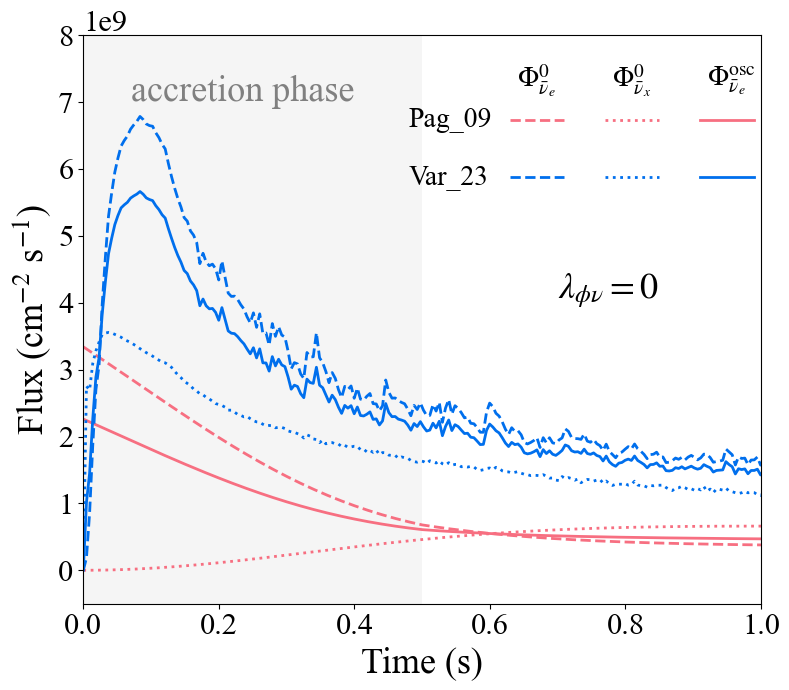

In [6]:
from Simulation_Spectrum import time_limit
import numpy as np
import matplotlib.pyplot as plt
import definition as df
from SignalRate_8p_osc import Flux_total_e, Flux_total_mu, Flux_total
from SignalRate_2d_osc import flux_2d_e, flux_2d_mu, flux_2d


color_1 = '#f76f81'
# color_2 = 'blue'
color_2 = '#006FED'
accretion_color = 'grey'
linewidth = 2.

ranges_K: list = [(0, 30), (7, 50),  (-1, 1)]

fix_0 = [10., 4.5, 4.5, 0.1, 2., 0.5, 0, -16]

t_space = np.linspace(0, 10, 1000)       # unit s
E_space = np.linspace(7, 50, 300)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

fig, ax = plt.subplots(figsize=(8, 7))

label_fontsize = 26
tick_fontsize = 22

y_e_1 = df.gl_integrate(lambda x: Flux_total_e(t_space, x, *fix_0), 7, 50)
y_x_1 = df.gl_integrate(lambda x: Flux_total_mu(t_space, x, *fix_0), 7, 50)
y_total_1 = df.gl_integrate(lambda x: Flux_total(t_space, x, *fix_0), 7, 50)

ax.plot(t_space, y_e_1, color = color_1, linestyle ='--', linewidth=linewidth)
ax.plot(t_space, y_x_1, color = color_1,linestyle =':', linewidth=linewidth)
ax.plot(t_space, y_total_1, color = color_1, linestyle = '-', linewidth=linewidth)

t_space_2 = np.linspace(0, time_limit('max'), 1000)

y_e_2 = df.gl_integrate(lambda x: flux_2d_e(t_space_2, x, *fix_0), 7, 50)
y_x_2 = df.gl_integrate(lambda x: flux_2d_mu(t_space_2, x, *fix_0), 7, 50)
y_total_2 =  df.gl_integrate(lambda x: flux_2d(t_space_2, x, *fix_0), 7, 50)

ax.plot(t_space_2, y_e_2, color = color_2, linestyle ='--', linewidth=linewidth)
ax.plot(t_space_2, y_x_2, color = color_2,linestyle =':', linewidth=linewidth)
ax.plot(t_space_2, y_total_2, color = color_2, linestyle = '-', linewidth=linewidth)

alpha_fill = 0.08
tau_a = fix_0[5]

ax.fill_betweenx(np.array([-2e9,2e10]), -0.1, tau_a, color = accretion_color, alpha = alpha_fill,  edgecolor = 'none')

# ax.vlines(0.65, ymin=0, ymax=3e10, color='red', linestyle='--', label = r'$\tau_a$')
ax.set_xlabel('Time (s)', fontsize=label_fontsize)
ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
ax.set_ylim(-5e8, 8e9)
ax.set_xlim(0, 1.)


# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.43+x_shift, 0.51+x_shift], [y_row1, y_row1], color=color_1, linestyle='--', transform=ax.transAxes, linewidth=linewidth)

# Second line and text (Phi_2)
ax.plot([0.57+x_shift, 0.65+x_shift], [y_row1, y_row1], color=color_1, linestyle=':', transform=ax.transAxes, linewidth=linewidth)

# Third line and text (Phi_3)
ax.plot([0.71+x_shift, 0.79+x_shift], [y_row1, y_row1], color=color_1, linestyle='-', transform=ax.transAxes, linewidth=linewidth)


# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.43+x_shift, 0.51+x_shift], [y_row2, y_row2], color=color_2, linestyle='--', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.44+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.57+x_shift, 0.65+x_shift], [y_row2, y_row2], color=color_2, linestyle=':', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.58+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.71+x_shift, 0.79+x_shift], [y_row2, y_row2], color=color_2, linestyle='-', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.72+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

ax.text(0.28+x_shift, y_row1, 'Pag_09', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)
ax.text(0.28+x_shift, y_row2, 'Var_23', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)
ax.text(0.07, 0.9, 'accretion phase', fontsize=label_fontsize, va='center', color='grey', transform=ax.transAxes)

ax.text(0.5+x_shift, y_row2-0.2, r'$\lambda_{\phi\nu} = 0$', fontsize=label_fontsize, va='center', transform=ax.transAxes)

plt.tight_layout()

plt.savefig(r'F:/Neutrino_SI/Plots/flux_osc.pdf')

fig

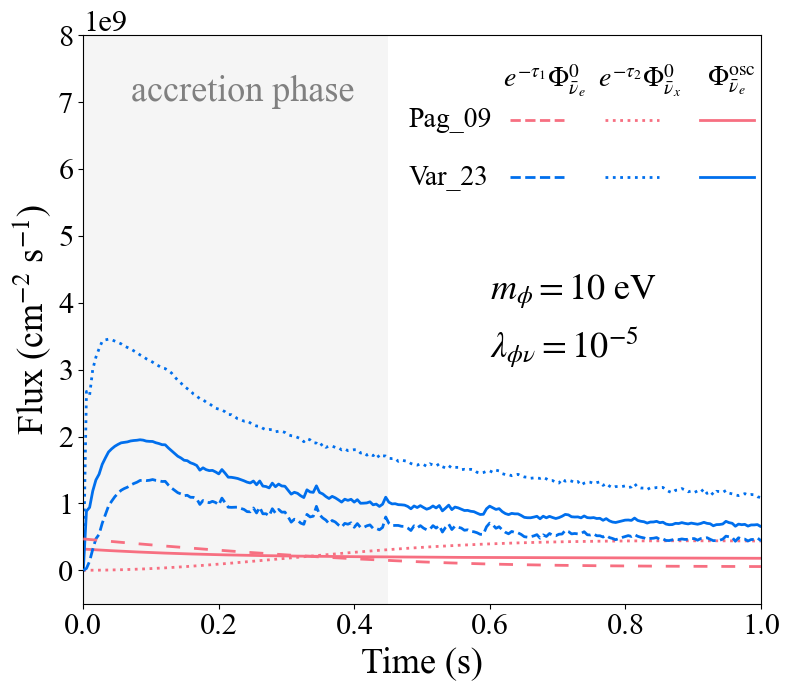

In [4]:
from Simulation_Spectrum import time_limit
import numpy as np
import matplotlib.pyplot as plt
import definition as df
from SignalRate_8p_osc import Flux_total_e, Flux_total, Flux_total_mu, Flux_total_tau
from SignalRate_2d_osc import flux_2d, flux_2d_mu, flux_2d_e, flux_2d_tau

ranges_K: list = [(0, 30), (7, 50),  (-1, 1)]

fix_0 = [11., 4.2, 4.5, 0.1, 2., 0.45, 1, -5]

t_space = np.linspace(0, 10, 1000)       # unit s
E_space = np.linspace(7, 50, 300)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

fig, ax = plt.subplots(figsize=(8, 7))

y_e_1_r = df.gl_integrate(lambda x: Flux_total_e(t_space, x, *fix_0), 7, 50)
y_mu_1_r = df.gl_integrate(lambda x: Flux_total_mu(t_space, x, *fix_0), 7, 50)
y_tau_1_r = df.gl_integrate(lambda x: Flux_total_tau(t_space, x, *fix_0), 7, 50)
y_total_1_r = df.gl_integrate(lambda x: Flux_total(t_space, x, *fix_0), 7, 50)

ax.plot(t_space, y_e_1_r, color = color_1, linestyle ='--', zorder=4, dashes=(5, 5), linewidth=linewidth)
ax.plot(t_space, y_mu_1_r, color = color_1,linestyle =':', linewidth=linewidth)
# ax.plot(t_space, y_tau_1_r, color = color_1,linestyle ='-.', linewidth=linewidth)
ax.plot(t_space, y_total_1_r, color = color_1, linestyle = '-', linewidth=linewidth)

t_space_2 = np.linspace(0, time_limit('max'), 1000)

flux_2 = lambda x: flux_2d(t_space_2, x, *fix_0)

y_e_2_r = df.gl_integrate(lambda x: flux_2d_e(t_space_2, x, *fix_0), 7, 50)
y_mu_2_r = df.gl_integrate(lambda x: flux_2d_mu(t_space_2, x, *fix_0), 7, 50)
y_tau_2_r = df.gl_integrate(lambda x: flux_2d_tau(t_space_2, x, *fix_0), 7, 50)
y_total_2_r =  df.gl_integrate(flux_2,  7, 50)

ax.plot(t_space_2, y_e_2_r, color = color_2, linestyle ='--', zorder=3, linewidth=linewidth)
ax.plot(t_space_2, y_mu_2_r, color = color_2,linestyle =':', linewidth=linewidth)
# ax.plot(t_space_2, y_tau_2_r, color = color_2,linestyle ='-.', linewidth=linewidth)
ax.plot(t_space_2, y_total_2_r, color = color_2, linestyle = '-', linewidth=linewidth)


ax.fill_betweenx(np.array([-2e9,2e10]), -0.1, tau_a, color = accretion_color, alpha = alpha_fill, label = 'accretion phase', edgecolor = 'none')

# ax.vlines(0.65, ymin=0, ymax=3e10, color='red', linestyle='--', label = r'$\tau_a$')
ax.set_xlabel('Time (s)', fontsize=label_fontsize)
ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
ax.set_ylim(-5e8, 0.8e10)
ax.set_xlim(0, 1.)



# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.43+x_shift, 0.51+x_shift], [y_row1, y_row1], color=color_1, linestyle='--', transform=ax.transAxes, linewidth=linewidth)

# Second line and text (Phi_2)
ax.plot([0.57+x_shift, 0.65+x_shift], [y_row1, y_row1], color=color_1, linestyle=':', transform=ax.transAxes, linewidth=linewidth)

# Third line and text (Phi_3)
ax.plot([0.71+x_shift, 0.79+x_shift], [y_row1, y_row1], color=color_1, linestyle='-', transform=ax.transAxes, linewidth=linewidth)


# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.43+x_shift, 0.51+x_shift], [y_row2, y_row2], color=color_2, linestyle='--', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.42+x_shift, y_row1+0.07, r'$e^{-\tau_1}\Phi_{\bar\nu_e}^0$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.57+x_shift, 0.65+x_shift], [y_row2, y_row2], color=color_2, linestyle=':', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.56+x_shift, y_row1+0.07, r'$e^{-\tau_2}\Phi_{\bar\nu_x}^0$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.71+x_shift, 0.79+x_shift], [y_row2, y_row2], color=color_2, linestyle='-', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.72+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)

ax.text(0.28+x_shift, y_row1, 'Pag_09', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)
ax.text(0.28+x_shift, y_row2, 'Var_23', fontsize=tick_fontsize-2, va='center', transform=ax.transAxes)
ax.text(0.07, 0.9, 'accretion phase', fontsize=label_fontsize, va='center', color='grey', transform=ax.transAxes)


ax.text(0.40+x_shift, y_row2-0.2, r'$m_\phi = 10 ~ {\rm eV}$', fontsize=label_fontsize, va='center', transform=ax.transAxes)
ax.text(0.40+x_shift, y_row2-0.3, r'$\lambda_{\phi\nu} = 10^{-5}$', fontsize=label_fontsize, va='center', transform=ax.transAxes)
plt.tight_layout()

plt.savefig(r'F:/Neutrino_SI/Plots/flux_osc_1.pdf')

fig

In [14]:
from Simulation_Spectrum import time_limit
from Simulation_Spectrum import flux_emulator_e, flux_emulator_x
import numpy as np
import matplotlib.pyplot as plt
import definition as df
from SignalRate_8p_osc import Flux_total_e, Flux_total_x, Flux_total
from SignalRate_2d_osc import flux_2d, flux_2d_e, flux_2d_x

ranges_K: list = [(0, 30), (7, 50),  (-1, 1)]

fix_0 = [11.33, 4.21, 4.49, 0.12, 2.01, 0.46, 2, -5]

t_space = np.linspace(0, 10, 1000)       # unit s
E_space = np.linspace(7, 50, 300)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' # STIX fonts look very similar to Times New Roman

fig, ax = plt.subplots(figsize=(8, 7))

label_fontsize = 22
tick_fontsize = 18

y_e_1_r = df.gl_integrate(lambda x: Flux_total_e(t_space, x, *fix_0), 7, 50)
y_x_1_r = df.gl_integrate(lambda x: Flux_total_x(t_space, x, *fix_0), 7, 50)
y_total_1_r = df.gl_integrate(lambda x: Flux_total(t_space, x, *fix_0), 7, 50)

ax.plot(t_space, y_e_1_r, color = color_1, linestyle ='--', zorder=4, dashes=(5, 5), linewidth=linewidth)
ax.plot(t_space, y_x_1_r, color = color_1,linestyle =':', linewidth=linewidth)
ax.plot(t_space, y_total_1_r, color = color_1, linestyle = '-', linewidth=linewidth)

t_space_2 = np.linspace(0, time_limit('max'), 1000)

flux_2 = lambda x: flux_2d(t_space_2, x, *fix_0)

y_e_2_r = df.gl_integrate(lambda x: flux_2d_e(t_space_2, x, *fix_0), 7, 50)
y_x_2_r = df.gl_integrate(lambda x: flux_2d_x(t_space_2, x, *fix_0), 7, 50)
y_total_2_r =  df.gl_integrate(flux_2,  7, 50)

ax.plot(t_space_2, y_e_2_r, color = color_2, linestyle ='-', zorder=3, linewidth=linewidth)
ax.plot(t_space_2, y_x_2_r, color = color_2,linestyle =':', linewidth=linewidth)
ax.plot(t_space_2, y_total_2_r, color = color_2, linestyle = '-', linewidth=linewidth)


ax.fill_betweenx(np.array([-2e9,2e10]), -0.1, tau_a, color = accretion_color, alpha = alpha_fill, label = 'accretion phase', edgecolor = 'none')

# ax.vlines(0.65, ymin=0, ymax=3e10, color='red', linestyle='--', label = r'$\tau_a$')
ax.set_xlabel('Time (s)', fontsize=label_fontsize)
ax.set_ylabel(r'Flux (cm$^{-2}$ s$^{-1}$)', fontsize=label_fontsize)
ax.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
ax.set_ylim(-5e8, 0.8e10)
ax.set_xlim(0, 1.)



# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row1, y_row1], color=color_1, linestyle='--', transform=ax.transAxes, linewidth=linewidth)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row1, y_row1], color=color_1, linestyle=':', transform=ax.transAxes, linewidth=linewidth)

# Third line and text (Phi_3)
ax.plot([0.70+x_shift, 0.76+x_shift], [y_row1, y_row1], color=color_1, linestyle='-', transform=ax.transAxes, linewidth=linewidth)


# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row2, y_row2], color=color_2, linestyle='--', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.51+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row2, y_row2], color=color_2, linestyle=':', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.61+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.7+x_shift, 0.76+x_shift], [y_row2, y_row2], color=color_2, linestyle='-', transform=ax.transAxes, linewidth=linewidth)
ax.text(0.71+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

ax.text(0.32+x_shift, y_row1, 'Paglia_09', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.32+x_shift, y_row2, 'Vartan_23', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.1, 0.9, 'accretion phase', fontsize=24, va='center', color='grey', transform=ax.transAxes)


ax.text(0.30+x_shift, y_row2-0.2, r'$m_\phi = 10^2 ~ {\rm eV} \quad \lambda_{\phi\nu} = 10^{-3}\frac{m_\nu}{T_\nu}$', fontsize=24, va='center', transform=ax.transAxes)

plt.tight_layout()

plt.savefig(r'F:/Neutrino_SI/Plots/flux_osc_2.pdf')

fig

ImportError: cannot import name 'flux_2d_x' from 'SignalRate_2d_osc' (F:\Neutrino_SI\Pycode\SignalRate_2d_osc.py)

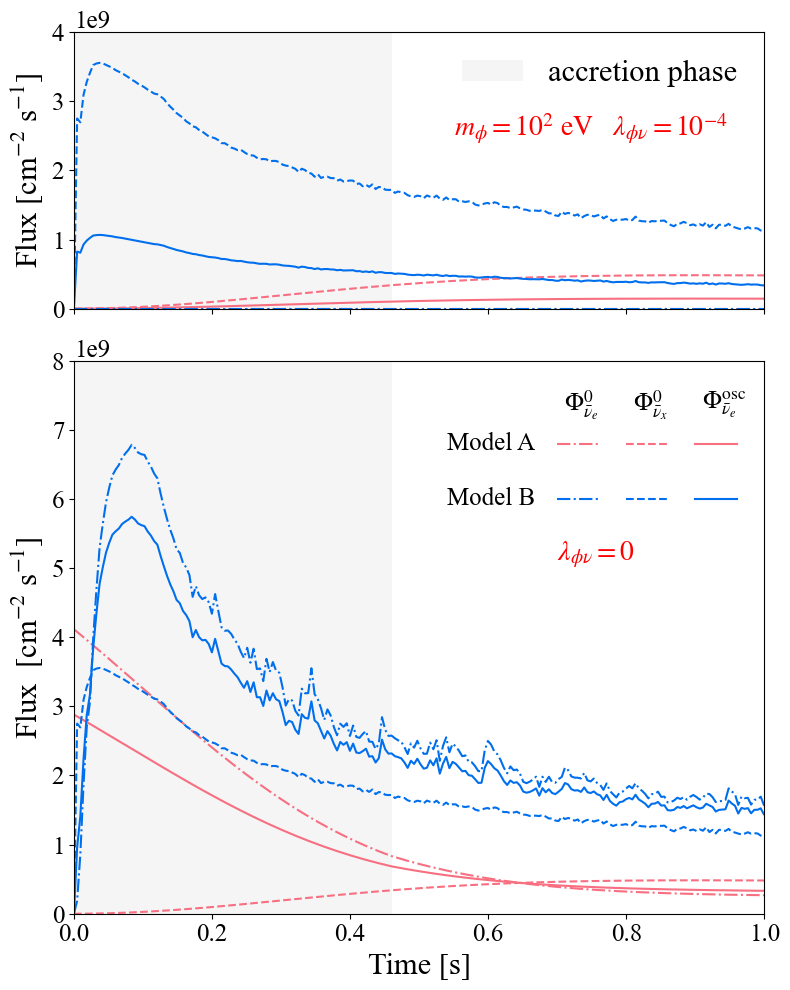

In [ ]:
# Creat a figure combining two figures with a shared x-axis

fig, (axr, ax) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(8, 10),gridspec_kw={'height_ratios': [1, 2]})

# ax bottom and axr top
ax.plot(t_space, y_e_1, color = color_1, linestyle ='-.')
ax.plot(t_space, y_x_1, color = color_1,linestyle ='--')
ax.plot(t_space, y_total_1, color = color_1, linestyle = '-')
ax.plot(t_space_2, y_e_2, color = color_2, linestyle ='-.')
ax.plot(t_space_2, y_x_2, color = color_2,linestyle ='--')
ax.plot(t_space_2, y_total_2, color = color_2, linestyle = '-') 
ax.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = accretion_color, alpha = alpha_fill,edgecolor = 'none')

axr.plot(t_space, y_e_1_r, color = color_1, linestyle ='-.')
axr.plot(t_space, y_x_1_r, color = color_1,linestyle ='--')
axr.plot(t_space, y_total_1_r, color = color_1, linestyle = '-')
axr.plot(t_space_2, y_e_2_r, color = color_2, linestyle ='-.')
axr.plot(t_space_2, y_x_2_r, color = color_2,linestyle ='--')
axr.plot(t_space_2, y_total_2_r, color = color_2, linestyle = '-')
axr.fill_betweenx(np.array([0,2e10]), -0.1, tau_a, color = accretion_color, alpha = alpha_fill, label = 'accretion phase', edgecolor = 'none')


ax.set_xlabel('Time [s]', fontsize=label_fontsize)
ax.set_ylabel(r'Flux  [cm$^{-2}$ s$^{-1}$]', fontsize=label_fontsize)
ax.set_xlim(0, 1.)
ax.set_ylim(0, 0.8e10)

axr.set_ylim(0, 0.4e10)
axr.set_ylabel(r'Flux [cm$^{-2}$ s$^{-1}$]', fontsize=label_fontsize)
axr.set_yticks([0, 0.1e10, 0.2e10, 0.3e10, 0.4e10])
plt.subplots_adjust(hspace=0.1)

axr.legend(fontsize=label_fontsize, loc='upper right', frameon=False)

ax.tick_params(labelsize=tick_fontsize)
axr.tick_params(labelsize=tick_fontsize)
ax.yaxis.get_offset_text().set_fontsize(tick_fontsize)
axr.yaxis.get_offset_text().set_fontsize(tick_fontsize)


# self-defined legend
x_shift = 0.2  # Horizontal shift for the text labels
y_shift = 0.05  # Vertical shift for the text labels

y_row1 = 0.80+y_shift  # Height of the first row (near the top)
y_row2 = 0.70+y_shift  # Height of the second row (slightly below row 1)

# ---------- ROW 1 (Purple) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row1, y_row1], color=color_1, linestyle='-.', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row1, y_row1], color=color_1, linestyle='--', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.70+x_shift, 0.76+x_shift], [y_row1, y_row1], color=color_1, linestyle='-', transform=ax.transAxes)

# ---------- ROW 2 (Blue) ----------

# First line and text (Phi_1)
ax.plot([0.50+x_shift, 0.56+x_shift], [y_row2, y_row2], color=color_2, linestyle='-.', transform=ax.transAxes)
ax.text(0.51+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Second line and text (Phi_2)
ax.plot([0.6+x_shift, 0.66+x_shift], [y_row2, y_row2], color=color_2, linestyle='--', transform=ax.transAxes)
ax.text(0.61+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_x}^0$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

# Third line and text (Phi_3)
ax.plot([0.7+x_shift, 0.76+x_shift], [y_row2, y_row2], color=color_2, linestyle='-', transform=ax.transAxes)
ax.text(0.71+x_shift, y_row1+0.07, r'$\Phi_{\bar\nu_e}^{\rm osc}$', fontsize=tick_fontsize, va='center', transform=ax.transAxes)

ax.text(0.34+x_shift, y_row1, 'Model A', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.34+x_shift, y_row2, 'Model B', fontsize=tick_fontsize, va='center', transform=ax.transAxes)
ax.text(0.5+x_shift, y_row2-0.1, r'$\lambda_{\phi\nu} = 0$', fontsize=20, va='center', transform=ax.transAxes, color = 'red')
axr.text(0.35+x_shift, y_row2-0.1, r'$m_\phi = 10^2 ~ {\rm eV} \quad \lambda_{\phi\nu} = 10^{-4}$', fontsize=20, va='center', transform=axr.transAxes, color = 'red')

# from matplotlib import patches
# ax.add_patch(patches.FancyBboxPatch((0.33+x_shift, 0.65+y_shift), 0.43, 0.25, fill=False, edgecolor=(0.5, 0.5, 0.5, 0.2), boxstyle="round,pad=0.02,rounding_size=0.03",
#     linewidth=0.8, transform=ax.transAxes))

plt.tight_layout()
fig.savefig(r'F:/Neutrino_SI/Plots/flux_osc_combined.pdf')

fig
